# Single-machine Scheduling

Minimizing weighted sum of WIP considering job deadlines:

1 | $C_j \leq d_j \; \forall j \in J$ | $\sum_{j \in J}{w_j C_j}$

A possible relaxation is given by ignoring dealine constraints, in which the optimal sequence of jobs is given by sorting them by $w_j / p_j$.

Stronger relaxations exploring lagrangian relaxations, besides dominance rules can be applied to make it more efficient, but to illustrate the library functionality, we will keep this basic example.

For a performatic example, try our `bnbprob` implementation:

```python
from bnbprob.machdeadline import LagrangianDeadline
```

In [1]:
from dataclasses import field

from pydantic.dataclasses import dataclass

from bnbpy import BranchAndBound, Problem, configure_logfile, plot_tree

In [2]:
configure_logfile('machine-deadline-example.log')

## Defining a Job

In [3]:

@dataclass(slots=True, frozen=True)
class Job:
    id: int
    """Job unique identifier"""
    p: int
    """Job processing time"""
    w: int
    """Job weight in objective function"""
    d: int
    """Job deadline"""
    pri: float = field(init=False, repr=False)
    """Job priority, calculated as w/p"""

    def __post_init__(self) -> None:
        object.__setattr__(self, 'pri', self.w / self.p)

    def __repr__(self):
        return f"Job({self.id})"


## Problem Class

In [4]:
LARGE_INT = 100000000


class MachDeadlineProb(Problem):
    _fixed: list[Job]
    """End sequence in reverse order,
    i.e. the last scheduled job is the first in the list"""
    _unscheduled: list[Job]
    """Unsceduled jobs, sorted by WSPT rule in correct order"""
    _fixed_term: int
    """Term of the objective function for the fixed part of the sequence"""
    _unscheduled_term: int
    """Term of the objective function for the unscheduled
    part of the sequence"""
    _violations: bool
    """Whether the current sequence has any deadline delay violation"""
    _unscheduled_total_time: int
    """Total processing time of the unscheduled jobs"""

    def __init__(self, jobs: list[Job]) -> None:
        super().__init__()
        self._fixed = []
        self._unscheduled = jobs.copy()
        self._fixed_term = 0
        self._unscheduled_term = 0
        self._violations = False
        self._unscheduled_total_time = sum(job.p for job in self._unscheduled)
        MachDeadlineProb.find_wspt(self._unscheduled)
        self._compute_completion_times()

    @property
    def sequence(self) -> list[Job]:
        return self._unscheduled + list(reversed(self._fixed))

    def write(self) -> str:
        return '->'.join([f'{job}' for job in self.sequence])

    def _compute_completion_times(self) -> None:
        last_c = 0
        self._violations = False
        self._unscheduled_term = 0
        for job in self._unscheduled:
            c = last_c + job.p
            last_c = c
            self._unscheduled_term += job.w * c
            if c > job.d:
                self._violations = True

    def calc_bound(self) -> int:
        return self._unscheduled_term + self._fixed_term

    def is_feasible(self) -> bool:
        return not self._violations

    def branch(self) -> list['MachDeadlineProb']:
        # Create one child for each possible job to schedule next
        children = []
        for job in self._unscheduled:
            # Early infeasibility check
            if job.d < self._unscheduled_total_time:
                continue
            child = self.child_copy(deep=False)
            child.fix_job(job)
            children.append(child)
        return children

    def fix_job(self, job: Job) -> None:
        self._fixed.append(job)
        self._unscheduled.remove(job)
        self._fixed_term += job.w * self._unscheduled_total_time
        self._unscheduled_total_time -= job.p
        self._compute_completion_times()

    def child_copy(self, deep: bool = True) -> 'MachDeadlineProb':
        other = super().child_copy(deep)
        # In case of a shallow copy,
        # we need to make sure to copy the mutable attributes.
        # Notice jobs are immutable, so we can just pass on the references.
        other._fixed = self._fixed.copy()
        other._unscheduled = self._unscheduled.copy()
        return other

    @staticmethod
    def find_wspt(jobs: list[Job]) -> None:
        jobs.sort(key=lambda job: job.pri, reverse=True)


## Solve

In [5]:
# Parameters
p = [4, 3, 8, 2, 7, 6]
w = [1, 1, 1, 1, 1, 1]
d = [10, 20, 20, 30, 30, 30]

# Instantiate problem
jobs = [Job(j, p[j], w[j], d[j]) for j in range(len(p))]
problem = MachDeadlineProb(jobs)
print(problem.calc_bound())

# Solve
bnb = BranchAndBound(problem, eval_node='in', save_tree=True)
sol = bnb.solve()
print(f'Nodes explored: {bnb.explored}')
print(sol)
print(sol.problem.write())

83
Nodes explored: 3
Status: OPTIMAL | Cost: 86.0 | LB: 86.0
Job(3)->Job(1)->Job(0)->Job(2)->Job(5)->Job(4)


## Visualize

Remember, by default the search tree is deleted from memory as nodes are fathomed. To keep it for illustration/debug purposes, initialize `BranchAndBound` with `save_tree=True`.

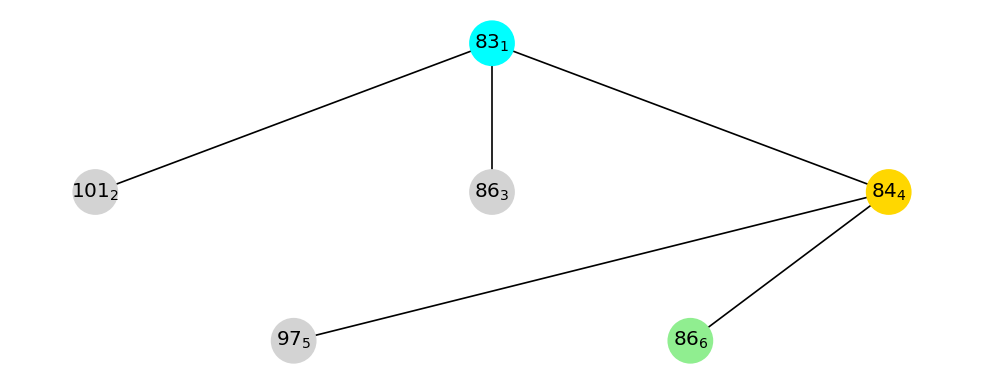

In [6]:
plot_tree(bnb.root, dpi=120, figsize=[8, 3])